In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=3.5)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 1, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [4]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64),
 Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64))

In [5]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []
    for t in np.arange(1,20,0.1):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,20,0.1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [6]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
)
df_quantum_3d

,states,prior,time,real,imag
0,0,Upper,0,-0.0009698304518587916,5.89534931288993e-19
1,1,Upper,0,-0.002909491355576375,-0.005118661374815365
2,2,Upper,0,0.015633096057400785,-0.025593306874076818
3,3,Upper,0,0.12095382899645078,0.004668614092033994
4,4,Upper,0,0.16613891518579585,0.31977538291667945
...,...,...,...,...,...
3985,2,Lower,189,-0.17445286510380148,-0.07508373167352882
3986,3,Lower,189,0.2161976365834795,-0.14978388825719036
3987,4,Lower,189,-0.14636937100753183,0.08541991765058538
3988,5,Lower,189,0.07093056315661178,-0.0170839835301171


In [17]:
import plotly.io as pio
pio.renderers


In [20]:
import plotly.express as px
pio.renderers.default = "vscode" #"browser"
px.line_3d(df_quantum_3d.query("prior == 'Upper'"), z="time", x="real", y="imag")

In [ ]:
intensity_matrix_markov

In [ ]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

In [9]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot

,states,prior,time,value
0,-3,Upper,0.0,0.000013
1,-2,Upper,0.0,0.000166
2,-1,Upper,0.0,0.001717
3,0,Upper,0.0,0.014567
4,1,Upper,0.0,0.096796
...,...,...,...,...
3985,-1,Lower,18.9,0.022821
3986,0,Lower,18.9,0.068451
3987,1,Lower,18.9,0.205394
3988,2,Lower,18.9,0.616488


In [ ]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")

/home/rkmalaiya/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



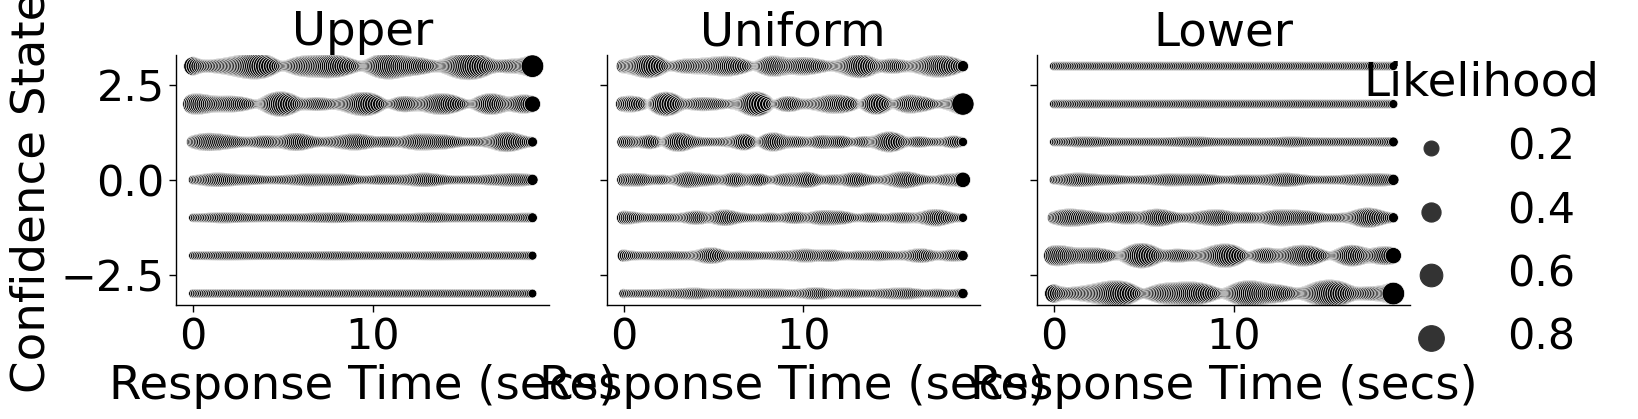

In [10]:
f = sns.relplot(df_quantum_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black")
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [ ]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

In [ ]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.01]]), npx.asarray([[0.1]]), npx.asarray([[0.5]]), npx.asarray([[1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []
        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        

In [ ]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_markov1_plot.query("value > 3")

In [ ]:
df_markov1_plot

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i

In [ ]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()